In [1]:
import numpy as np
import polars as pl
import pandas as pd
import tensorflow as tf
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from working_data import clean_cols, add_timing, alt_label_df as label_df, normalize_by_window, split_df, add_rsi, add_bollinger_bands, split_multiresolution_chunks
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from model_builder_trans import recommended_trading_loss as combined_loss
from dataset_generator import DatasetConfig, create_chunked_dataset_generator
from transformer_builder import LearnablePositionalEncoding, StochasticGatedTransformerBlock, WarmupCosineDecay
from tensorflow.keras.layers import Input, Conv1D,  Dense, concatenate, LayerNormalization, Dropout, Layer, GlobalAveragePooling1D, GlobalMaxPooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding


2025-06-17 17:46:47.118228: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-17 17:46:47.215375: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-17 17:46:48.126620: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-06-17 17:46:49.534771: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-06-17 17:46:49.684575: 

In [2]:
NORMALIZING_WINDOW_SIZE = 6*24
LABELING_WINDOW_SIZE = 18
POSITIVE_SLOPE = 0.3
NEGATIVE_SLOPE = 0.7
STARTING_HOUR = 0
ENDING_HOUR = 25
LABEL_CUR_CANDLE_MULTIPLIER = 0
LABEL_MEAN_MULTIPLIER = 6
BATCH_SIZE = 128
NUM_TOKENS = 64
OTHER_TOKENS = 64
LOOKBACK_WINDOW = NUM_TOKENS + 1
D_MODEL = 480
FF_DIM = D_MODEL* 2
NUM_HEADS = D_MODEL//24
DRAWDOWN = 0.5
LABEL_LOOKBACK = 512

In [3]:
source_csv = "olderdata/GBPUSD/five_minutes.csv"
source_2_csv = "olderdata/GBPUSD/hours.csv"
working_path = "split_data"

In [4]:
df = pd.read_csv(source_csv)
df = clean_cols(df)
df = add_timing(df)
df = normalize_by_window(
    df, 
    window_size=NORMALIZING_WINDOW_SIZE, 
    low_col='low',
    high_col='high',
    normalizing_cols=[
        'open',
        'high',
        'low',
        'close'
    ],
    label_cols=['open', 'close'])
print("labeling")
df = label_df(df, window_size=LABELING_WINDOW_SIZE, 
              mean_multiplier=LABEL_MEAN_MULTIPLIER, 
              cur_candle_multiplier=LABEL_CUR_CANDLE_MULTIPLIER, 
              positive_slope=POSITIVE_SLOPE, 
              negative_slope=NEGATIVE_SLOPE,
              starting_hour=STARTING_HOUR,
              ending_hour=ENDING_HOUR,
              drawdown=DRAWDOWN,
              lookback_window=LABEL_LOOKBACK)

df_alt = pd.read_csv(source_2_csv)
df_alt = clean_cols(df_alt)
df_alt = normalize_by_window(
    df_alt, 
    window_size=NORMALIZING_WINDOW_SIZE, 
    low_col='low',
    high_col='high',
    normalizing_cols=[
        'open',
        'high',
        'low',
        'close'
    ],
    label_cols=['open', 'close'])
df_alt.to_csv(os.path.join(working_path, 'larger_frame.csv'), index=False)

split_multiresolution_chunks(df_5min=df,
                             df_hour=df_alt,
                             dump_path=working_path,
                             chunk_size=12000,
                             hour_lookback=OTHER_TOKENS,
                             lookback=OTHER_TOKENS,
                             cols=[
                                'time',
                                'position_in_hour',
                                'hour_of_day',
                                'open',
                                'high',
                                'low',
                                'close',
                                'open_normalized',
                                'high_normalized',
                                'low_normalized',
                                'close_normalized',
                                'include',
                                'target'
                            ])

labeling


{'total_chunks': 26,
 'total_original_rows': 300820,
 'chunks_info': [{'chunk_num': 0,
   'start_idx': 0,
   'end_idx': 12000,
   'total_rows': 12000,
   'train_rows': 8399,
   'val_rows': 1736,
   'test_rows': 1737,
   'start_time': 1609761600,
   'end_time': 1614743700,
   'hour_start_pos': -1},
  {'chunk_num': 1,
   'start_idx': 12000,
   'end_idx': 24000,
   'total_rows': 12000,
   'train_rows': 8399,
   'val_rows': 1736,
   'test_rows': 1737,
   'start_time': 1614744000,
   'end_time': 1619726100,
   'hour_start_pos': 868},
  {'chunk_num': 2,
   'start_idx': 24000,
   'end_idx': 36000,
   'total_rows': 12000,
   'train_rows': 8399,
   'val_rows': 1736,
   'test_rows': 1737,
   'start_time': 1619726400,
   'end_time': 1624881900,
   'hour_start_pos': 1868},
  {'chunk_num': 3,
   'start_idx': 36000,
   'end_idx': 48000,
   'total_rows': 12000,
   'train_rows': 8399,
   'val_rows': 1736,
   'test_rows': 1737,
   'start_time': 1624882200,
   'end_time': 1629864300,
   'hour_start_pos'

In [5]:
auc =  tf.keras.metrics.AUC()
auc.reset_state()
prec = tf.keras.metrics.Precision()
prec.reset_state()

In [6]:
hour_path = "split_data/hour.csv"
train_path = "split_data/training"
val_path = "split_data/validation"
test_path = "split_data/testing"
feature_cols = [
    'open_normalized',
    'high_normalized',
    'low_normalized',
    'close_normalized'
]

train_config = DatasetConfig(
        main_data_dir=train_path,
        hourly_data_path=hour_path,
        main_lookback_tokens=NUM_TOKENS,
        hourly_lookback_tokens=OTHER_TOKENS,
        lookback_window=LOOKBACK_WINDOW,
        batch_size=BATCH_SIZE,
        apply_smote=True,
        shuffle_data=True,
        feature_columns=feature_cols,
        max_chunks_in_memory=100
    )

val_config = DatasetConfig(
        main_data_dir=val_path,
        hourly_data_path=hour_path,
        main_lookback_tokens=NUM_TOKENS,
        hourly_lookback_tokens=OTHER_TOKENS,
        lookback_window=LOOKBACK_WINDOW,
        batch_size=BATCH_SIZE,
        apply_smote=False,
        shuffle_data=False,
        feature_columns=feature_cols,
        max_chunks_in_memory=100
    )

test_config = DatasetConfig(
        main_data_dir=test_path,
        hourly_data_path=hour_path,
        main_lookback_tokens=NUM_TOKENS,
        hourly_lookback_tokens=OTHER_TOKENS,
        lookback_window=LOOKBACK_WINDOW,
        batch_size=BATCH_SIZE,
        apply_smote=False,
        shuffle_data=False,
        feature_columns=feature_cols,
        max_chunks_in_memory=100
    )

train_dataset, train_rows = create_chunked_dataset_generator(
    config=train_config,
    repeat_dataset=True
)
val_dataset, val_rows = create_chunked_dataset_generator(
    config=val_config,
    repeat_dataset=True
)
test_dataset, test_rows = create_chunked_dataset_generator(
    config=test_config,
    repeat_dataset=True
)

train_steps = train_rows//BATCH_SIZE
val_steps = val_rows//BATCH_SIZE
test_steps = test_rows//BATCH_SIZE

2025-06-17 17:47:46,121 - INFO - Discovered 26 chunk files
2025-06-17 17:47:46,122 - INFO - Loading hourly data...
2025-06-17 17:47:46,166 - INFO - Loaded hourly data: 24941 rows
2025-06-17 17:47:46,169 - INFO - Applied time threshold: 1610640000
2025-06-17 17:47:46,169 - INFO - Building global indices...
2025-06-17 17:47:46,833 - INFO - Built indices: 4687 positive, 69947 negative samples
2025-06-17 17:47:46,833 - INFO - Dataset info: {'total_chunks': 26, 'positive_samples': 4687, 'negative_samples': 69947, 'hourly_data_rows': 24941, 'time_threshold': 1610640000, 'feature_columns': ['open_normalized', 'high_normalized', 'low_normalized', 'close_normalized']}
2025-06-17 17:47:46,882 - INFO - Discovered 26 chunk files
2025-06-17 17:47:46,883 - INFO - Loading hourly data...
2025-06-17 17:47:46,886 - INFO - Loaded hourly data: 24941 rows
2025-06-17 17:47:46,887 - INFO - Applied time threshold: 1610640000
2025-06-17 17:47:46,887 - INFO - Building global indices...
2025-06-17 17:47:47,029 -

In [7]:
def create_model(training=True):
    # Main (5-minute) data input
    input_shape = (NUM_TOKENS, len(feature_cols))
    input_layer = Input(shape=input_shape, name='minute_input')
    
    # Hourly data input
    other_input_shape = (OTHER_TOKENS, len(feature_cols))
    other_input_layer = Input(shape=other_input_shape, name='hourly_input')
    
    # Custom layer for adding type embeddings
    class AddTypeEmbedding(Layer):
        def __init__(self, type_id, embed_dim=16, **kwargs):
            super().__init__(**kwargs)
            self.type_id = type_id
            self.embed_dim = embed_dim
            self.embedding_layer = None
            
        def build(self, input_shape):
            self.embedding_layer = Embedding(input_dim=2, output_dim=self.embed_dim, name=f'{self.name}_embed')
            super().build(input_shape)
            
        def call(self, inputs):
            batch_size = tf.shape(inputs)[0]
            seq_len = tf.shape(inputs)[1]
            type_ids = tf.fill((batch_size, seq_len), self.type_id)
            type_embed = self.embedding_layer(type_ids)
            return tf.concat([inputs, type_embed], axis=-1)
            
        def get_config(self):
            config = super().get_config()
            config.update({
                "type_id": self.type_id,
                "embed_dim": self.embed_dim
            })
            return config
    
    # Improved CNN block function
    def cnn_feature_extractor(inputs, name_prefix, max_filter_output=D_MODEL-16):
        # Multi-scale feature extraction
        x = Conv1D(filters=max_filter_output//2, kernel_size=3, activation='relu', padding="same", name=f'{name_prefix}_conv1')(inputs)      
        x = Conv1D(filters=max_filter_output, kernel_size=5, activation='relu', padding="same", name=f'{name_prefix}_conv3')(x)
   
        return x
    
    # Process 5-minute data branch
    x = cnn_feature_extractor(input_layer, '5min', D_MODEL-16)
    x = Dense(D_MODEL - 16, name='5min_projection')(x)  # Reserve 16 dims for type embedding
    x = LearnablePositionalEncoding(maxlen=NUM_TOKENS, d_model=D_MODEL - 16)(x)
    
    # Add type embedding for 5-minute data (type 0)
    x = AddTypeEmbedding(type_id=0, embed_dim=16, name='5min_type_embed')(x)

    # Process hourly data branch
    h = cnn_feature_extractor(other_input_layer, 'hourly', D_MODEL-16)
    h = Dense(D_MODEL - 16, name='hourly_projection')(h)  # Reserve 16 dims for type embedding
    h = LearnablePositionalEncoding(maxlen=OTHER_TOKENS, d_model=D_MODEL - 16)(h)
    
    # Add type embedding for hourly data (type 1)
    h = AddTypeEmbedding(type_id=1, embed_dim=16, name='hourly_type_embed')(h)

    x = concatenate([h, x], axis=1, name='timeframe_concat')  # Shape: (batch, time_combined, d_model)
    x = Dropout(0.1)(x)

    # Deeper transformer stack with increasing stochastic depth
    stochastic_rates = [0.1, 0.2]
    for i in range(2):  # 6 transformer blocks
        x = StochasticGatedTransformerBlock(
            D_MODEL, NUM_HEADS, FF_DIM, 
            rate=0.1, 
            attention_dropout=stochastic_rates[i], 
            stochastic_depth_rate=stochastic_rates[i],
        )(x, training=training)

    # Global pooling with layer norm
    avg_pool = GlobalAveragePooling1D(name='avg_pool')(x)
    max_pool = GlobalMaxPooling1D(name='max_pool')(x)
    
    # Additional feature: attention-weighted pooling
    class AttentionPooling(Layer):
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.attention_dense = Dense(1)  # Remove activation here
            
        def call(self, inputs):
            # inputs shape: (batch_size, seq_len, hidden_dim)
            attention_logits = self.attention_dense(inputs)  # (batch_size, seq_len, 1)
            attention_weights = tf.nn.softmax(attention_logits, axis=1)  # Softmax across sequence
            return tf.reduce_sum(inputs * attention_weights, axis=1)
            
        def get_config(self):
            config = super().get_config()
            return config
    
    attention_pool = AttentionPooling(name='attention_pooling')(x)
    
    combined_features = concatenate([avg_pool, max_pool, attention_pool], name='combined_features')
    combined_features = Dropout(0.2)(combined_features)
    # combined_features = Dropout(0.2)(attention_pool)

    dense_out = Dense(D_MODEL, activation='relu', name='pre_output_dense')(combined_features)
    dense_out = Dropout(0.1)(dense_out)
    
    outputs = Dense(1, activation='sigmoid', name='output')(dense_out)

    # Create model
    model = Model(inputs=[input_layer, other_input_layer], outputs=outputs)
    
    return model

model = create_model(training=True)

lr_schedule = WarmupCosineDecay(initial_lr=5e-4, warmup_steps=3000, decay_steps=40000)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# Compile the model
model.compile(
    optimizer=optimizer, 
    loss=combined_loss, 
    metrics=['accuracy', auc, prec])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ hourly_input        │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ minute_input        │ (None, 64, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_conv1        │ (None, 64, 232)   │      3,016 │ hourly_input[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ 5min_conv1 (Conv1D) │ (None, 64, 232)   │      3,016 │ minute_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_conv3        │ (None, 64, 464)   │    538,704 │ hourly_conv1[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ 5min_conv3 (Conv1D) │ (None, 64, 464)   │    538,704 │ 5min_conv1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_projection   │ (None, 64, 464)   │    215,760 │ hourly_conv3[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ 5min_projection     │ (None, 64, 464)   │    215,760 │ 5min_conv3[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ learnable_position… │ (None, 64, 464)   │     29,696 │ hourly_projectio… │
│ (LearnablePosition… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ learnable_position… │ (None, 64, 464)   │     29,696 │ 5min_projection[… │
│ (LearnablePosition… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hourly_type_embed   │ (None, 64, 480)   │         32 │ learnable_positi… │
│ (AddTypeEmbedding)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ 5min_type_embed     │ (None, 64, 480)   │         32 │ learnable_positi… │
│ (AddTypeEmbedding)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ timeframe_concat    │ (None, 128, 480)  │          0 │ hourly_type_embe… │
│ (Concatenate)       │                   │            │ 5min_type_embed[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 480)  │          0 │ timeframe_concat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stochastic_gated_t… │ (None, 128, 480)  │  2,310,240 │ dropout[0][0]     │
│ (StochasticGatedTr… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stochastic_gated_t… │ (None, 128, 480)  │  2,310,240 │ stochastic_gated… │
│ (StochasticGatedTr… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ avg_pool            │ (None, 480)       │          0 │ stochastic_gated… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pool            │ (None, 480)       │          0 │ stochastic_gated

 Total params: 6,887,538 (26.27 MB)

 Trainable params: 6,887,538 (26.27 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stopping = EarlyStopping(monitor='val_loss', 
                               patience=10, # Stops if there's no improvement for 3 epochs
                               mode='min', 
                               verbose=1)

model_checkpoint = ModelCheckpoint('best_multiresolution_model.keras', 
                                   monitor='val_loss', 
                                   save_best_only=True, 
                                   mode='min', 
                                   verbose=1)

# Train the model using the train and validation datasets
history = model.fit(
    train_dataset,
    epochs=50,
    steps_per_epoch=train_steps,
    validation_data=val_dataset,
    validation_steps=val_steps,
    callbacks=[early_stopping, model_checkpoint]
)


Epoch 1/50


I0000 00:00:1750175275.075374   25010 service.cc:145] XLA service 0x7f6e2c002990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750175275.075542   25010 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
2025-06-17 17:47:55.238304: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
W0000 00:00:1750175275.407007   25010 random_ops.cc:59] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. functional_1/stochastic_gated_transformer_block_1/random_uniform/RandomUniform
2025-06-17 17:47:56.071515: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907
I0000 00:00:1750175283.293948   25306 asm_compiler.cc:369] ptxas warning : Registers are

1083/1092 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - accuracy: 0.5395 - auc: 0.5640 - loss: 0.1948 - precision_1: 0.5746

I0000 00:00:1750175486.824530   25934 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_479', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1750175488.468344   25947 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_53', 164 bytes spill stores, 168 bytes spill loads



1092/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.5396 - auc: 0.5642 - loss: 0.1946 - precision_1: 0.5750
Epoch 1: val_loss improved from inf to 0.33912, saving model to best_multiresolution_model.keras
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 261s 212ms/step - accuracy: 0.5396 - auc: 0.5643 - loss: 0.1946 - precision_1: 0.5751 - val_accuracy: 0.9257 - val_auc: 0.6438 - val_loss: 0.3391 - val_precision_1: 0.2324
Epoch 2/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.5776 - auc: 0.6320 - loss: 0.1483 - precision_1: 0.7512

I0000 00:00:1750175738.512481   26764 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_42', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1750175740.661878   26754 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_17', 164 bytes spill stores, 168 bytes spill loads




Epoch 2: val_loss did not improve from 0.33912
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 236s 216ms/step - accuracy: 0.5776 - auc: 0.6320 - loss: 0.1483 - precision_1: 0.7512 - val_accuracy: 0.9374 - val_auc: 0.5445 - val_loss: 0.3426 - val_precision_1: 0.0000e+00
Epoch 3/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.5638 - auc: 0.6122 - loss: 0.1601 - precision_1: 0.6993
Epoch 3: val_loss did not improve from 0.33912
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 253s 232ms/step - accuracy: 0.5638 - auc: 0.6122 - loss: 0.1601 - precision_1: 0.6993 - val_accuracy: 0.8810 - val_auc: 0.6345 - val_loss: 0.3719 - val_precision_1: 0.1643
Epoch 4/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.5825 - auc: 0.6569 - loss: 0.1378 - precision_1: 0.8006
Epoch 4: val_loss did not improve from 0.33912
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 243s 223ms/step - accuracy: 0.5825 - auc: 0.6569 - loss: 0.1378 - precision_1: 0.8006 - val_accuracy: 0.9233 - val_auc: 0.6502 - val_loss: 0.3418 - val_precision_1: 

In [9]:
# Inspect the dataset structure
for data in train_dataset.take(1):
    for i, item in enumerate(data):
        print(data[0][0][0][-1][-1])
        print('\n\n\n\n')
        print(data[0][1][0][-1][-1])
        break

tf.Tensor(0.63380283, shape=(), dtype=float32)





tf.Tensor(0.56508696, shape=(), dtype=float32)


2025-06-17 18:44:11.607208: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [10]:
model = create_model(training=False)
model.load_weights('best_multiresolution_model.keras')

# Make predictions
predictions = model.predict(test_dataset, steps=test_steps)

# Convert probabilities to binary class (0 or 1) using a threshold of 0.5
predicted_class = (predictions > 0.5).astype(int)

115/115 ━━━━━━━━━━━━━━━━━━━━ 22s 158ms/step


Confusion Matrix:
 [[13285   493]
 [  805   137]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     13778
           1       0.22      0.15      0.17       942

    accuracy                           0.91     14720
   macro avg       0.58      0.55      0.56     14720
weighted avg       0.90      0.91      0.90     14720



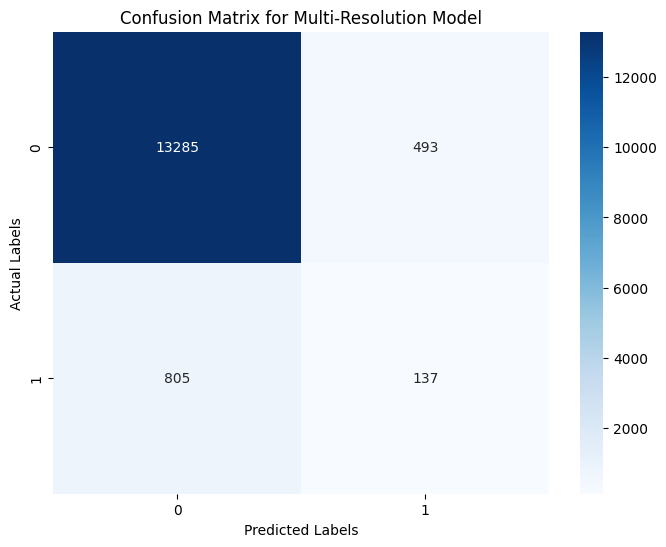

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Collect ground truth labels
y_true = []
for inputs in test_dataset:
    # The test_dataset now returns a tuple of two inputs and one target
    if len(inputs) == 3:  # If unpacked
        minute_input, hourly_input, target = inputs
    else:  # If not unpacked
        target = inputs[-1]
    y_true.extend(target.numpy())
    # Break if we've processed all the steps
    if len(y_true) >= test_steps * BATCH_SIZE:
        break

# Truncate to match the length of predictions
y_true = y_true[:len(predicted_class)]

# Create the confusion matrix
conf_matrix = confusion_matrix(y_true, predicted_class)

print("Confusion Matrix:\n", conf_matrix)

# Generate classification report
print("\nClassification Report:")
print(classification_report(y_true, predicted_class))

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.title('Confusion Matrix for Multi-Resolution Model')
plt.show()

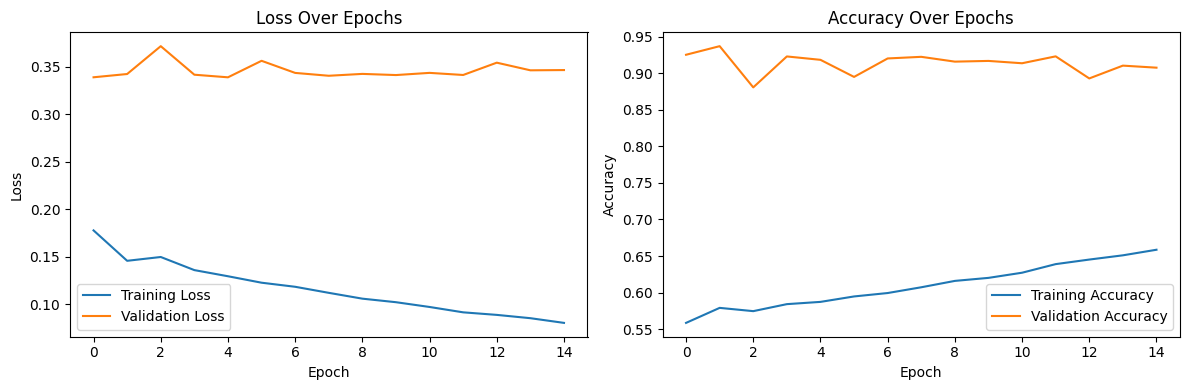

In [12]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()